## 多层感知机
### 隐藏层
我们可以通过在网络中加入一个或多个隐藏层来克服线性模型的限制， 使其能处理更普遍的函数关系类型。 要做到这一点，最简单的方法是将许多全连接层堆叠在一起。 每一层都输出到上面的层，直到生成最后的输出。 我们可以把前L-1层看作表示，把最后一层看作线性预测器。 这种架构通常称为多层感知机（multilayer perceptron），通常缩写为MLP。
#### 从线性到非线性
仿射函数的仿射函数本身就是仿射函数， 但是我们之前的线性模型已经能够表示任何仿射函数。为了发挥多层架构的潜力， 我们还需要一个额外的关键要素： 在仿射变换之后对每个隐藏单元应用非线性的激活函数（activation function）$\sigma $激活函数的输出（例如，$\sigma(\cdot)$）被称为活性值（activations）。 一般来说，有了激活函数，就不可能再将我们的多层感知机退化成线性模型.
多层感知机可以通过隐藏神经元，捕捉到输入之间复杂的相互作用， 这些神经元依赖于每个输入的值。 我们可以很容易地设计隐藏节点来执行任意计算。 例如，在一对输入上进行基本逻辑操作，多层感知机是通用近似器。 即使是网络只有一个隐藏层，给定足够的神经元和正确的权重， 我们可以对任意函数建模，尽管实际中学习该函数是很困难的。 神经网络有点像C语言。 C语言和任何其他现代编程语言一样，能够表达任何可计算的程序。 但实际上，想出一个符合规范的程序才是最困难的部分。
而且，虽然一个单隐层网络能学习任何函数， 但并不意味着我们应该尝试使用单隐藏层网络来解决所有问题。 


#### 激活函数
激活函数（activation function）通过计算加权和并加上偏置来确定神经元是否应该被激活， 它们将输入信号转换为输出的可微运算。 大多数激活函数都是非线性的。 由于激活函数是深度学习的基础，下面简要介绍一些常见的激活函数。

In [1]:
import torch
from d2l import torch as d2l

##### ReLU函数
最受欢迎的激活函数是修正线性单元（Rectified linear unit，ReLU）， 因为它实现简单，同时在各种预测任务中表现良好。 ReLU提供了一种非常简单的非线性变换。 给定元素x，ReLU函数被定义为该元素与0的最大值：$$\mathrm{ReLU}(x)=\max(x,0).$$通俗地说，ReLU函数通过将相应的活性值设为0，仅保留正元素并丢弃所有负元素。 为了直观感受一下，我们可以画出函数的曲线图。 正如从图中所看到，激活函数是分段线性的。

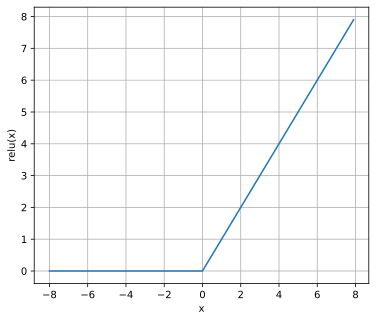

In [2]:
x = torch.arange(-8.0,8.0,0.1,requires_grad=True)
y = torch.relu(x)
d2l.plot(x.detach(),y.detach(),'x','relu(x)',figsize=(6,5))

当输入为负时，ReLU函数的导数为0，而当输入为正时，ReLU函数的导数为1。 注意，当输入值精确等于0时，ReLU函数不可导。 在此时，我们默认使用左侧的导数，即当输入为0时导数为0。 我们可以忽略这种情况，因为输入可能永远都不会是0。 下面我们绘制ReLU函数的导数。

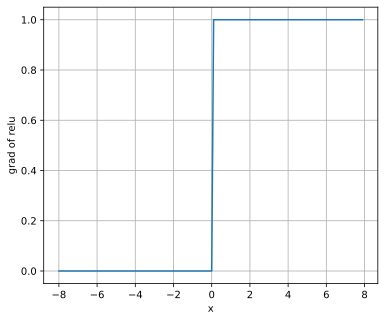

In [3]:
y.backward(torch.ones_like(x),retain_graph=True)
d2l.plot(x.detach(),x.grad,'x','grad of relu',figsize=(6,5))

使用ReLU的原因是，它求导表现得特别好：要么让参数消失，要么让参数通过。 这使得优化表现得更好，并且ReLU减轻了困扰以往神经网络的梯度消失问题（稍后将详细介绍）。

注意，ReLU函数有许多变体，包括参数化ReLU（Parameterized ReLU，pReLU） 函数 (He et al., 2015)。 该变体为ReLU添加了一个线性项，因此即使参数是负的，某些信息仍然可以通过：$$\mathrm{pReLU}(x)=\max(0,x)+\alpha\min(0,x).$$

##### sigmoid函数
sigmoid函数将输入变换为区间(0, 1)上的输出。 因此，sigmoid通常称为挤压函数（squashing function）： 它将范围（-inf, inf）中的任意输入压缩到区间（0, 1）中的某个值：$$\mathrm{sigmoid}(x)=\frac1{1+\exp(-x)}.$$当人们逐渐关注到到基于梯度的学习时， sigmoid函数是一个自然的选择，因为它是一个平滑的、可微的阈值单元近似。 当我们想要将输出视作二元分类问题的概率时， sigmoid仍然被广泛用作输出单元上的激活函数 （sigmoid可以视为softmax的特例）。 然而，sigmoid在隐藏层中已经较少使用， 它在大部分时候被更简单、更容易训练的ReLU所取代。下面，我们绘制sigmoid函数。 注意，当输入接近0时，sigmoid函数接近线性变换。

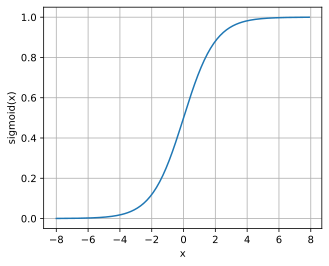

In [4]:
y = torch.sigmoid(x)
d2l.plot(x.detach(),y.detach(),'x','sigmoid(x)',figsize=(5,4))

sigmoid函数的导数为下面的公式:$$\frac d{dx}\mathrm{sigmoid}(x)=\frac{\exp(-x)}{(1+\exp(-x))^2}=\mathrm{sigmoid}(x)\left(1-\mathrm{sigmoid}(x)\right).$$ sigmoid函数的导数图像如下所示。 注意，当输入为0时，sigmoid函数的导数达到最大值0.25； 而输入在任一方向上越远离0点时，导数越接近0。

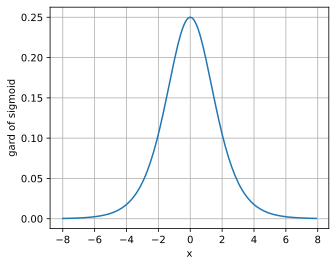

In [6]:
# 清除以前的梯度
x.grad.data.zero_()
y.backward(torch.ones_like(x),retain_graph=True)
d2l.plot(x.detach(),x.grad,'x','gard of sigmoid',figsize=(5,4))

##### tanh函数
与sigmoid函数类似， tanh(双曲正切)函数也能将其输入压缩转换到区间(-1, 1)上。 tanh函数的公式如下：$$\tanh(x)=\frac{1-\exp(-2x)}{1+\exp(-2x)}.$$ 下面我们绘制tanh函数。 注意，当输入在0附近时，tanh函数接近线性变换。 函数的形状类似于sigmoid函数， 不同的是tanh函数关于坐标系原点中心对称。

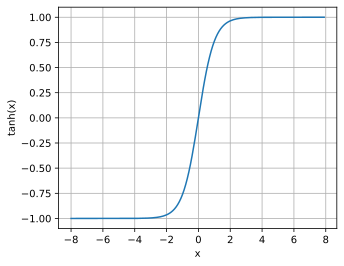

In [7]:
y = torch.tanh(x)
d2l.plot(x.detach(),y.detach(),'x','tanh(x)',figsize=(5,4))

tanh的导数是:$$\frac d{dx}\mathrm{tanh}(x)=1-\mathrm{tanh}^2(x).$$ tanh函数的导数图像如下所示。 当输入接近0时，tanh函数的导数接近最大值1。 与我们在sigmoid函数图像中看到的类似， 输入在任一方向上越远离0点，导数越接近0。

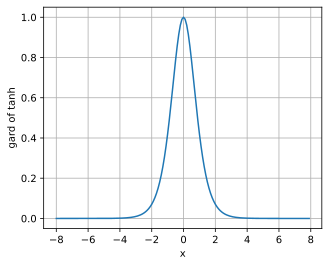

: 

In [8]:
# 清除以前的梯度
x.grad.data.zero_()
y.backward(torch.ones_like(x),retain_graph=True)
d2l.plot(x.detach(),x.grad,'x','gard of tanh',figsize=(5,4))